In [1]:
from IPython.core.magic import register_cell_magic
@register_cell_magic
def skip(line, cell):
    return

from working_cooling import *
from working_peaks import *

plt.ion()
%matplotlib ipympl

In [2]:
%%skip
key = 'cooling_fid'
#key = 'sph_fid'
k = 75
env = MyEnv(key)
z = 4 if (k <= env.Next + env.Nsh4) else 1
sh_data = open_rundata(key, z)
sh_data = cellsBehindShock_fromData(sh_data)
cell_data = open_celldata(key, k)
shocked_data = cell_data.loc[(cell_data.Sd == 0)].copy().iloc[1:]
cell_d0 = sh_data.loc[sh_data.i==cell_data.iloc[0].i].iloc[0]
cell_rad, _ = generate_cell_withDistrib(cell_data, cell_d0, env)

In [3]:
%%skip
popt_lfac = fit_celldata(cell_data, ['lfac'], [get_variable(cell_d0, 'lfac', env)],
    env, cell_d0.x)[0]
popt_lfac0 = fit_celldata(cell_data, ['lfac'], [get_variable(cell_d0, 'lfac', env)],
    env, cell_d0.x, beta=0.)[0]
plot_data('lfac', shocked_data, env, cell_d0)
x_sh = shocked_data.x.to_numpy() / cell_d0.x
r_sh = shocked_data.x.to_numpy() * c_/env.R0
r_sh = r_sh[x_sh>=1]
x_sh = x_sh[x_sh>=1]
print(x_sh[-1])
plt.plot(r_sh, smooth_bpl_apy(x_sh, *popt_lfac), ls='--', c='k')
plt.plot(r_sh, smooth_bpl_apy(x_sh, *popt_lfac0), ls=':', c='k')

In [4]:
%%skip
x = np.geomspace(1, 5)
plt.figure()
label1 = f'$\\alpha = {popt_lfac[-3]:.2f}, \\beta= {popt_lfac[-2]:.2f}$'
label0 = f'$\\alpha = {popt_lfac0[-3]:.2f}, \\beta= {popt_lfac0[-2]:.2f}$'
plt.plot(x, smooth_bpl_apy(x, *popt_lfac), ls='--', c='k', label=label1)
plt.plot(x, smooth_bpl_apy(x, *popt_lfac0), ls=':', c='k', label=label0)
plt.legend()


In [5]:
key1 = 'cooling_fid'
key2 = 'cooling_alpha=10'
k = 75
lognu_min, lognu_max = -4, 3
### Computation over one cell
nuobs1, Tobs1, env1, nF1, cell1 = get_cell_nuFnu(key1, k, lognu_min=lognu_min, lognu_max=lognu_max, return_cell=True)
nuobs2, Tobs2, env2, nF2, cell2 = get_cell_nuFnu(key2, k, lognu_min=lognu_min, lognu_max=lognu_max, return_cell=True)
nuobs3, Tobs3, env3, nF3, cell3 = get_cell_nuFnu(key1, k, lognu_min=lognu_min, lognu_max=lognu_max, alpha=10, return_cell=True)
gma_m1, gma_c1, gma_M1 = get_critlfacs(cell1, env1)
nup_m1, nup_c1, nup_M1 = get_critfreqs(cell1, env1, normed=True)
gma_m2, gma_c2, gma_M2 = get_critlfacs(cell2, env2)
nup_m2, nup_c2, nup_M2 = get_critfreqs(cell2, env2, normed=True)
gma_m3, gma_c3, gma_M3 = get_critlfacs(cell3, env3)
nup_m3, nup_c3, nup_M3 = get_critfreqs(cell3, env3, normed=True)
Tb1 = (Tobs1-env1.Ts)/env1.T0
Tb2 = (Tobs2-env2.Ts)/env2.T0
Tb3 = (Tobs3-env3.Ts)/env3.T0
nub1 = nuobs1/(1.5*env1.nu0)
nub2 = nuobs2/(1.5*env2.nu0)
nub3 = nuobs3/(1.5*env3.nu0)
ratio1 = gma_c1/gma_m1
ratio2 = gma_c2/gma_m2
ratio3 = gma_c3/gma_m3
label1 = f'$\\gamma_c/\\gamma_m=${sci_notation(ratio1)}'
label2 = f'$\\gamma_c/\\gamma_m=${sci_notation(ratio2)}'
label3 = f'$\\gamma_c/\\gamma_m=${sci_notation(ratio1)}, $\\alpha=10$'


/tmp/ipykernel_7424/1776802789.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


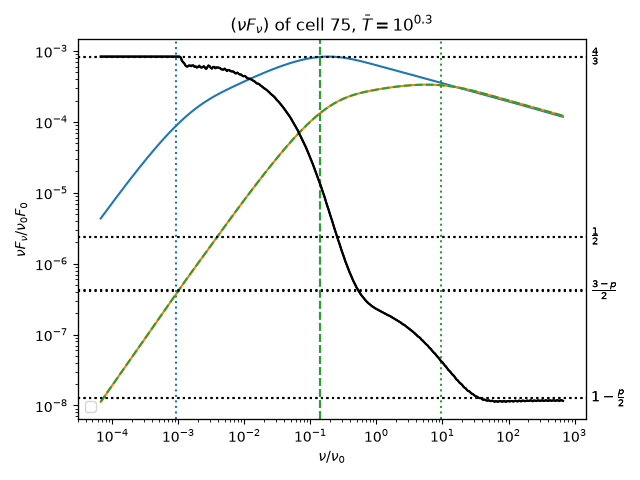

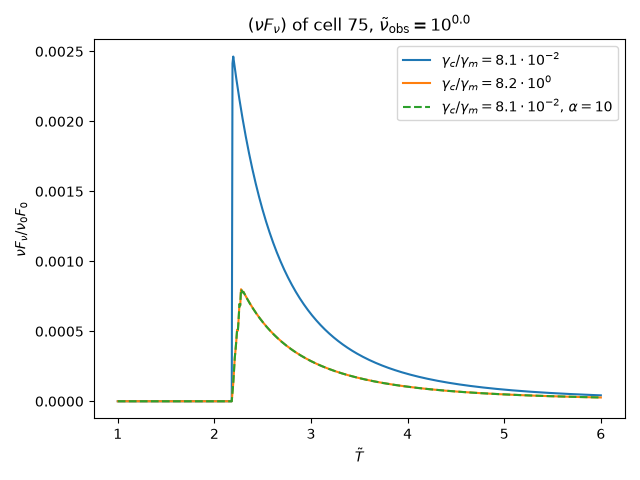

In [6]:
logT = 0.3
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)$ of cell {k}, $\\bar{{T}}=10^{{{logT:.1f}}}$')
plot_spectrum(logT, Tb1, nub1, nF1, ax_in=ax, label=label1)
#ylims = ax.get_ylim()
#ax.set_ylim(ylims)
plot_spectrum(logT, Tb2, nub2, nF2, slopes=True, ax_in=ax, ls='-', label=label2)
plot_spectrum(logT, Tb3, nub3, nF3, slopes=True, ax_in=ax, ls='--', label=label3)
ax.axvline(nup_m1, c='C0', ls='--')
ax.axvline(nup_c1, c='C0', ls=':')
ax.axvline(nup_m3, c='C2', ls='--')
ax.axvline(nup_c3, c='C2', ls=':')
ax.set_xlabel(nu_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()
lognu = 0
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)$ of cell {k}, $\\tilde{{\\nu}}_{{\\rm obs}}=10^{{{lognu:.1f}}}$')
plot_lightcurve(lognu, Tb1, nub1, nF1, ax_in=ax, label=label1)
plot_lightcurve(lognu, Tb2, nub2, nF2, ax_in=ax, ls='-', label=label2)
plot_lightcurve(lognu, Tb3, nub3, nF3, ax_in=ax, ls='--', label=label3)
ax.set_xlabel(T_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()

In [7]:

key1 = 'cooling_fid'
key2 = 'cooling_alpha=10'
lognu_min, lognu_max = -4, 3
### Full shell computation
z = 4
nuobs1, Tobs1, env1, nF1 = get_shell_nuFnu(key1, z, lognu_min=lognu_min, lognu_max=lognu_max, NT=100, Nnu=100)
nuobs2, Tobs2, env2, nF2 = get_shell_nuFnu(key2, z, lognu_min=lognu_min, lognu_max=lognu_max, NT=100, Nnu=100)
nuobs3, Tobs3, env3, nF3 = get_shell_nuFnu(key1, z, lognu_min=lognu_min, lognu_max=lognu_max, NT=100, Nnu=100, alpha=10)
Tb1 = (Tobs1-env1.Ts)/env1.T0
Tb2 = (Tobs2-env2.Ts)/env2.T0
Tb3 = (Tobs3-env3.Ts)/env3.T0
nub1 = nuobs1/(1.5*env1.nu0)
nub2 = nuobs2/(1.5*env2.nu0)
nub3 = nuobs3/(1.5*env3.nu0)
ratio1 = env1.gma_c/env1.gma_m
ratio2 = env2.gma_c/env2.gma_m
ratio3 = env3.gma_c/env3.gma_m


In [8]:
sh_data1 = open_rundata(key1, z)
sh_data1 = cellsBehindShock_fromData(sh_data1)
sh_data2 = open_rundata(key2, z)
sh_data2 = cellsBehindShock_fromData(sh_data2)
gma_m1, gma_c1, gma_M1 = get_shell_critlfacs(sh_data1, env1)
nup_m1, nup_c1, nup_M1 = get_shell_critfreqs(sh_data1, env1, normed=True)
gma_m2, gma_c2, gma_M2 = get_shell_critlfacs(sh_data2, env2)
nup_m2, nup_c2, nup_M2 = get_shell_critfreqs(sh_data2, env2, normed=True)


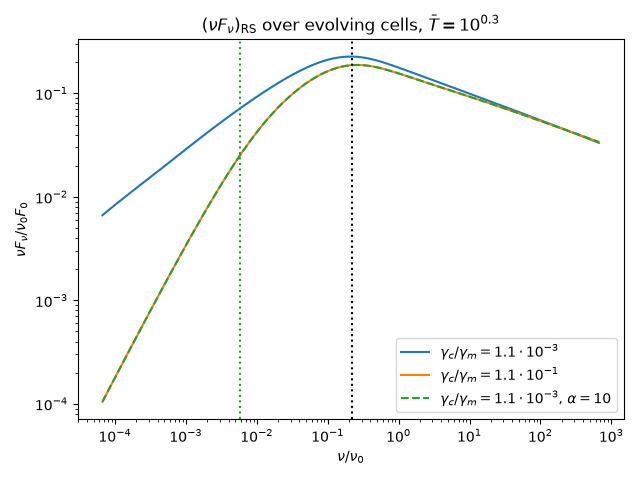

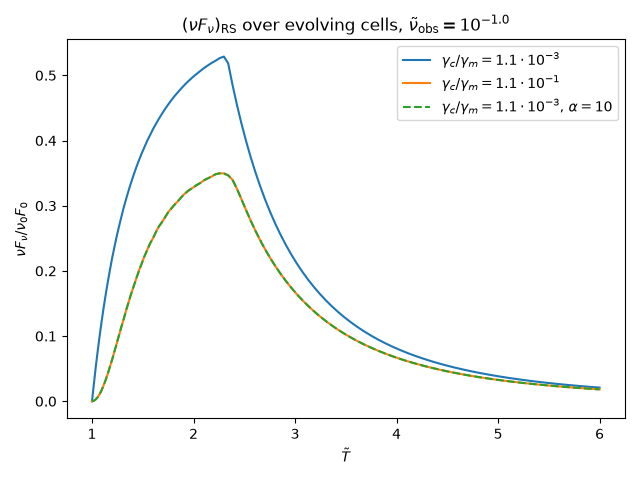

In [9]:

logT = 0.3
label1 = f'$\\gamma_c/\\gamma_m=${sci_notation(ratio1)}'
label2 = f'$\\gamma_c/\\gamma_m=${sci_notation(ratio2)}'
label3 = f'$\\gamma_c/\\gamma_m=${sci_notation(ratio1)}, $\\alpha=10$'
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)_{{\\rm RS}}$ over evolving cells, $\\bar{{T}}=10^{{{logT:.1f}}}$')
plot_spectrum(logT, Tb1, nub1, nF1, ax_in=ax, label=label1)
plot_spectrum(logT, Tb2, nub2, nF2, ax_in=ax, ls='-', label=label2)
plot_spectrum(logT, Tb3, nub3, nF3, ax_in=ax, ls='--', label=label3)
#ax.axvline(nup_c1, ls=':', c='C0')
ax.axvline(1/(1.5*(1+10**logT)), ls=':', c='k')
ax.axvline(nup_c2, ls=':', c='C2')
ax.set_xlabel(nu_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()
lognu = -1
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)_{{\\rm RS}}$ over evolving cells, $\\tilde{{\\nu}}_{{\\rm obs}}=10^{{{lognu:.1f}}}$')
plot_lightcurve(lognu, Tb1, nub1, nF1, ax_in=ax, label=label1)
plot_lightcurve(lognu, Tb2, nub2, nF2, ax_in=ax, ls='-', label=label2)
plot_lightcurve(lognu, Tb3, nub3, nF3, ax_in=ax, ls='--', label=label3)
ax.set_xlabel(T_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()

In [ ]:
key = 'cooling_fid'
k = 75
alpha = 10
env = MyEnv(key)
z = 4 if (k <= env.Next + env.Nsh4) else 1
sh_data = open_rundata(key, z)
sh_data = cellsBehindShock_fromData(sh_data)
cell_data = open_celldata(key, k)
cell_d0 = sh_data.loc[sh_data.i==cell_data.iloc[0].i].iloc[0]
# rarefaction launch point (shell-exit interface), as in get_cell_nuFnu
exit_row = sh_data.loc[sh_data.t.idxmax()]
cell_rad,    env_a  = generate_cell_withDistrib(cell_data, cell_d0, env,
                        key=key, k=k, exit_row=exit_row)
cell_rad_sc, env_sc = generate_cell_withDistrib(cell_data, cell_d0, env, alpha=alpha,
                        key=key, k=k, exit_row=exit_row)


In [ ]:
### cooling steps: cooling_fid cell 75, alpha=1 vs alpha=10
key = 'cooling_fid'; k = 75; logT = 0
nuobs1, Tobs1, env1, nF1, cell1 = get_cell_nuFnu(key, k, lognu_min=-3, lognu_max=5, return_cell=True)
nuobs2, Tobs2, env2, nF2, cell2 = get_cell_nuFnu(key, k, alpha=10, lognu_min=-3, lognu_max=5, return_cell=True)
ax = compare_cellspectra_withsteps(logT, [cell1, cell2],
    [nuobs1, nuobs2], [Tobs1, Tobs2], [env1, env2],
    labels=[r'$\alpha=1$', r'$\alpha=10$'])
ax.set_title(f'cell {k} cooling steps, $\\bar{{T}}=10^{{{logT:.1f}}}$')


In [ ]:
### cooling steps: cooling_fid cell 75, alpha=1 vs alpha=10
# each cell keeps its own env so the rescaling stays self-consistent in obs space
logT = 0.3
nub, T, _ = obs_arrays(key, normed=True, lognu_min=-4, lognu_max=3)
nuobs    = nub*env.nu0;       Tobs    = env.Ts    + (T-1)*env.T0
nuobs_sc = nub*env_sc.nu0;    Tobs_sc = env_sc.Ts + (T-1)*env_sc.T0
ax = compare_cellspectra_withsteps(logT, [cell_rad, cell_rad_sc],
    [nuobs, nuobs_sc], [Tobs, Tobs_sc], [env, env_sc],
    labels=[r'$\alpha=1$', r'$\alpha=10$'])
ax.set_title(f'cell {k} cooling steps, $\\bar{{T}}=10^{{{logT:.1f}}}$')

In [ ]:
key = 'fid_au=2_u1=10'
#key = 'sph_fid'
k = 450
env = MyEnv(key)
z = 4 if (k <= env.Next + env.Nsh4) else 1
sh_data = open_rundata(key, z)
sh_data = cellsBehindShock_fromData(sh_data)
cell_data = open_celldata(key, k)
if cell_data is False:
  extract_data_cells(key, [k], noOut=True)
  cell_data = open_celldata(key, k)
cell_d0 = sh_data.loc[sh_data.i==cell_data.iloc[0].i].iloc[0]
fig, ax = plt.subplots()
plot_data('rho', cell_data, env, cell_d0, ax_in=ax)
#plot_data('Sd', cell_data, env, ax_in=ax)
x0 = cell_d0.x
popt_rho = fit_celldata(cell_data, ['rho'], [cell_d0.rho], env, x0=x0)[0]
sd = cell_data.Sd.to_numpy()
ish = np.flatnonzero(sd != 0)
after = np.flatnonzero(sd[ish[0]:] == 0)
start = ish[0] + after[0] + 1 if len(after) else len(sd)
shocked_data = cell_data.iloc[start:].copy()
x = shocked_data.x.to_numpy() / x0
y = smooth_bpl_apy(x, *popt_rho)
x_ = shocked_data.x.to_numpy() * c_ / env.R0
plt.plot(x_, smooth_bpl_apy(x, *popt_rho), ls='--', c='k')

## 1. 'bruteforce' et comparaison
Pas besoin que ça soit opti, d'abord avoir un résultat

### A. extraction des données
- données en snapshots -> données en cellules et données du choc
- fit données choc, reconstruire données downstream avec R_cr/R_0
- fit des données cellules, normalisées par attentes du downstream


In [ ]:
fig, ax = plt.subplots()
for key in ['fid_au=2_u1=100', 'fid_au=2_u1=10']:
  env = MyEnv(key)
  plot_earlydata('rho', 'rho3_sc', key, ax_in=ax, label=f'$u_1={env.u1}$')
plt.legend()

In [ ]:

### One cell in thinshell approximation
k = 450
nuobs1, Tobs1, env1, nF1 = get_cell_thinshell_nuFnu('fid_au=2_u1=100', k)
nuobs2, Tobs2, env2, nF2 = get_cell_thinshell_nuFnu('fid_au=2_u1=10', k)
nuobs3, Tobs3, env3, nF3 = get_cell_thinshell_nuFnu('fid_au=2_u1=10', k, u_scale=10)
Tb1 = (Tobs1-env1.Ts)/env1.T0
Tb2 = (Tobs2-env2.Ts)/env2.T0
Tb3 = (Tobs3-env3.Ts)/env3.T0
nub1 = nuobs1/(1.5*env1.nu0)
nub2 = nuobs2/(1.5*env2.nu0)
nub3 = nuobs3/(1.5*env3.nu0)
logT = 0
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)$ of cell {k} in thinshell approx., $\\bar{{T}}=10^{{{logT:.1f}}}$')
plot_spectrum(logT, Tb1, nub1, nF1, ax_in=ax, label='$u_1=100$')
ylims = ax.get_ylim()
ax.set_ylim(ylims)
plot_spectrum(logT, Tb2, nub2, nF2, ax_in=ax, ls='--', label='$u_1=10$')
plot_spectrum(logT, Tb3, nub3, nF3, ax_in=ax, ls='--', label='$(u_1=10)\\times 10$')
ax.set_xlabel(nu_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()
lognu = -2
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)$ of cell {k} in thinshell approx., $\\tilde{{\\nu}}_{{\\rm obs}}=10^{{{lognu:.1f}}}$')
plot_lightcurve(lognu, Tb1, nub1, nF1, ax_in=ax, label='$u_1=100$')
plot_lightcurve(lognu, Tb2, nub2, nF2, ax_in=ax, ls='--', label='$u_1=10$')
plot_lightcurve(lognu, Tb3, nub3, nF3, ax_in=ax, ls='--', label='$(u_1=10)\\times 10$')
ax.set_xlabel(T_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()

In [ ]:
### Thinshell approximation
nuobs1, Tobs1, env1, nF1 = get_thinshell_nuFnu('fid_au=2_u1=100', cutoff=True)
nuobs2, Tobs2, env2, nF2 = get_thinshell_nuFnu('fid_au=2_u1=10', cutoff=True)
nuobs3, Tobs3, env3, nF3 = get_thinshell_nuFnu('fid_au=2_u1=10', u_scale=10, cutoff=True)
Tb1 = (Tobs1-env1.Ts)/env1.T0
Tb2 = (Tobs2-env2.Ts)/env2.T0
Tb3 = (Tobs3-env3.Ts)/env3.T0
nub1 = nuobs1/(1.5*env1.nu0)
nub2 = nuobs2/(1.5*env2.nu0)
nub3 = nuobs3/(1.5*env3.nu0)
logT = 0
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)_{{\\rm RS}}$ in the thinshell approximation, $\\bar{{T}}=10^{{{logT:.1f}}}$')
plot_spectrum(logT, Tb1, nub1, nF1, ax_in=ax, label='$u_1=100$')
ylims = ax.get_ylim()
ax.set_ylim(ylims)
plot_spectrum(logT, Tb2, nub2, nF2, ax_in=ax, ls='--', label='$u_1=10$')
plot_spectrum(logT, Tb3, nub3, nF3, ax_in=ax, ls='--', label='$(u_1=10)\\times 10$')
ax.set_xlabel(nu_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()
lognu = -2
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)_{{\\rm RS}}$ in the thinshell approximation, $\\tilde{{\\nu}}_{{\\rm obs}}=10^{{{lognu:.1f}}}$')
plot_lightcurve(lognu, Tb1, nub1, nF1, ax_in=ax, label='$u_1=100$')
plot_lightcurve(lognu, Tb2, nub2, nF2, ax_in=ax, ls='--', label='$u_1=10$')
plot_lightcurve(lognu, Tb3, nub3, nF3, ax_in=ax, ls='--', label='$(u_1=10)\\times 10$')
ax.set_xlabel(T_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()

In [ ]:
### Full shell computation
z = 4
nuobs1, Tobs1, env1, nF1 = get_shell_nuFnu('fid_au=2_u1=100', z)
nuobs2, Tobs2, env2, nF2 = get_shell_nuFnu('fid_au=2_u1=10', z)
nuobs3, Tobs3, env3, nF3 = get_shell_nuFnu('fid_au=2_u1=10', z, u_scale=10)
Tb1 = (Tobs1-env1.Ts)/env1.T0
Tb2 = (Tobs2-env2.Ts)/env2.T0
Tb3 = (Tobs3-env3.Ts)/env3.T0
nub1 = nuobs1/(1.5*env1.nu0)
nub2 = nuobs2/(1.5*env2.nu0)
nub3 = nuobs3/(1.5*env3.nu0)

In [ ]:
logT = 0
fig, ax = plt.subplots()
#plt.title(f'$(\\nu F_\\nu)_{{\\rm RS}}$ over evolving cells, $\\bar{{T}}=10^{{{logT:.1f}}}$')
nuobs_ts, Tobs_ts, env_ts, nF_ts = get_thinshell_nuFnu('fid_au=2_u1=100', cutoff=True)
plot_spectrum(logT, Tb1, nub1, nF1, ax_in=ax, label='syn')
Tb_ts = (Tobs_ts-env_ts.Ts)/env_ts.T0
nub_ts = nuobs_ts/(env_ts.nu0)
plot_spectrum(logT, Tb_ts, nub_ts, nF_ts, ax_in=ax, label='vfc')
plt.legend()
plt.tight_layout()

In [ ]:
logT = 0
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)_{{\\rm RS}}$ over evolving cells, $\\bar{{T}}=10^{{{logT:.1f}}}$')
plot_spectrum(logT, Tb1, nub1, nF1, ax_in=ax, label='$u_1=100$')
ylims = ax.get_ylim()
ax.set_ylim(ylims)
plot_spectrum(logT, Tb2, nub2, nF2, ax_in=ax, ls='--', label='$u_1=10$')
plot_spectrum(logT, Tb3, nub3, nF3, ax_in=ax, ls='--', label='$(u_1=10)\\times 10$')
ax.set_xlabel(nu_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()
lognu = -2
fig, ax = plt.subplots()
plt.title(f'$(\\nu F_\\nu)_{{\\rm RS}}$ over evolving cells, $\\tilde{{\\nu}}_{{\\rm obs}}=10^{{{lognu:.1f}}}$')
plot_lightcurve(lognu, Tb1, nub1, nF1, ax_in=ax, label='$u_1=100$')
plot_lightcurve(lognu, Tb2, nub2, nF2, ax_in=ax, ls='--', label='$u_1=10$')
plot_lightcurve(lognu, Tb3, nub3, nF3, ax_in=ax, ls='--', label='$(u_1=10)\\times 10$')
ax.set_xlabel(T_label)
ax.set_ylabel(nF_label)
plt.legend()
plt.tight_layout()

In [ ]:
key = 'log_au=0.0_chi=1.0'
#key = 'sph_fid'
k = 400
env = MyEnv(key)
z = 4 if (k <= env.Next + env.Nsh4) else 1
sh_data = open_rundata(key, z)
sh_data = cellsBehindShock_fromData(sh_data)
cell_data = open_celldata(key, k)
if cell_data is False:
  extract_data_cells(key, [k], noOut=True)
  cell_data = open_celldata(key, k)
cell_d0 = sh_data.loc[sh_data.i==cell_data.iloc[0].i].iloc[0]

### B. calcul
- utiliser les fits pour reconstruire données cellules semi-analytiquement, avec pas de temps déterminé par cooling
- faire évoluer $\gamma_{\min}, \gamma_{\max}$ sur ça
- calculer émission cellules
- sommer

In [ ]:
u_scale=1.
cell_dist, env_new = generate_cell_withDistrib(cell_data, cell_d0, env, u_scale, cleanData=True)
cell_cst = generate_cell_constLfac(cell_dist, env_new)

In [ ]:
%%skip
plt.figure()
x = cell_dist.x *c_ / env.R0
plt.loglog(x, cell_dist.gmax, c='C1', label='$\\gamma_{\\max}$')
plt.loglog(x, cell_cst.gmax, c='k', ls='--')
plt.loglog(x, cell_dist.gmin, c='C0', label='$\\gamma_{\\min}$')
plt.loglog(x, cell_cst.gmin, c='k', ls='--')
plt.legend()
err_gmin = np.abs(cell_cst.gmin-cell_dist.gmin)/cell_dist.gmin
err_gmax = np.abs(cell_cst.gmax-cell_dist.gmax)/cell_dist.gmax
plt.twinx()
plt.loglog(x, err_gmax, c='C1', ls=':')
plt.loglog(x, err_gmin, c='C0', ls=':')

In [ ]:
nuobs, Tobs, env = obs_arrays(key, lognu_min=-2.5, lognu_max=2.5, Nnu=400)
nu_resc = 1.5
Tb = (Tobs - env.Ts)/(env.T0 if z==4 else env.T0FS)
nub = nuobs/(nu_resc*(env.nu0 if z==4 else env.nu0FS))
nuFnu_sph = get_nuFnu(get_Fnu_cell_evolving, nuobs, Tobs, cell_dist, env)
#nF_hyb = get_nuFnu(get_Fnu_cell_evolving, nuobs, Tobs, cell_cst, env)
#nF_sph_inst = get_nuFnu(get_Fnu_cell_instant, nuobs, Tobs, cell_dist, env)
#nF_hyb_inst = get_nuFnu(get_Fnu_cell_instant, nuobs, Tobs, cell_cst, env)
nuFnu_thsh = get_nuFnu(get_Fnu_vFC, nuobs, Tobs, cell_d0, env, cutoff=True, nu_resc=nu_resc)

In [ ]:
nF_arr = [nuFnu_thsh, nuFnu_sph]
compare_spectra(0.2, Tb, nub, nF_arr, labels=['Band vFC + cutoff', 'syn. cooling'])
plt.legend()
plt.ylabel(nF_label)
plt.xlabel(nu_label)
plt.title('Contribution of 1 numerical cell')

In [ ]:
%%skip
Fnu_sph = get_Fnu_shell(key, z, nuobs, Tobs, cleanData=True)
#Fnu_sphVFC = get_Fnu_shell(key, z, nuobs, Tobs, VFC=True, cleanData=True)
file = 'computed_Fnu_fullsyn'
np.savez(file, Fnu_sph=Fnu_sph, Fnu_sphVFC=Fnu_sphVFC)

In [ ]:
%%skip
file = 'computed_Fnu_fullsyn.npz'
loaded = np.load(file)
Fnu_sph = loaded['Fnu_sph']
Fnu_sphVFC = loaded['Fnu_sphVFC']

In [ ]:
%%skip
nuFnu_sph = nub[np.newaxis, :] * Fnu_sph
nuFnu_sphVFC = nub[np.newaxis, :] * Fnu_sphVFC

In [ ]:
nuFnu_thsh = run_nuFnu_vFC(nuobs, Tobs, sh_data, env, norm=True, cutoff=True)

In [ ]:
nF_arr = [nuFnu_thsh, nuFnu_sph]
compare_spectra(0.2, Tb, nub, nF_arr, labels=['Band vFC + cutoff', 'syn. cooling'])
plt.legend()
plt.ylabel(nF_label)
plt.xlabel(nu_label)
plt.title('Full shell computation')

### C. Tests
- comparer cellule sphérique avec cellule planaire + géométrie (B constant et $\rho$ en $R^{-2}$) ; comparer leur somme sur la simu
- comparer cooling calculé avec vFC imposé ($\gamma_{min}, \gamma_{\max} \rightarrow 1$ dès le 1er pas) ; comparer leur somme sur la simu
- comparer flux total obtenu avec méthode C25, commencer par comparer pics puis spectre

In [ ]:
%%skip
lfac2_sh, ShSt_sh, _, _, _ = get_hydrofits_shell(sh_data)
print("Gamma^2 sh: ", lfac2_sh)
print("ShSt sh:", ShSt_sh)
plt.figure()
x = sh_data.x.to_numpy() * c_ / env.R0
val = get_variable(sh_data, 'lfac', env)/env.lfac0
fit = np.sqrt(smooth_bpl0(x, *lfac2_sh))
plt.plot(x, val, label='$\\Gamma$')
plt.plot(x, fit, ls='--', c='k')
val = get_variable(sh_data, 'ShSt', env)/(env.lfac34-1)
fit = smooth_bpl0(x, *ShSt_sh)
plt.plot(x, val, label='$\\Gamma_{ud}-1$')
plt.plot(x, fit, ls='--', c='k')
plt.legend()

## Important
the scaling of a given cell after it has been shocked is not the same as the scaling behind the shock front! Also the initial values for $\Gamma^2$ and $\Gamma_{ud}-1$ need to be those from the fit behind the shock to reflect its propagation

In [ ]:
%%skip
lfac2_cell, ShSt_cell = get_hydrofits_shell(cell_data)
print("Gamma^2 sh: ", lfac2_cell)
print("ShSt sh:", ShSt_cell)
plt.figure()
x = cell_data.x.to_numpy() * c_ / env.R0
val = get_variable(cell_data, 'lfac', env)/env.lfac0
fit = np.sqrt(smooth_bpl0(x, *lfac2_cell))
plt.plot(x, val, label='$\\Gamma$')
plt.plot(x, fit, ls='--', c='k')
val = get_variable(cell_data, 'ShSt', env)/(env.lfac34-1)
fit = smooth_bpl0(x, *ShSt_cell)
plt.plot(x, val, label='$\\Gamma_{ud}-1$')
plt.plot(x, fit, ls='--', c='k')
plt.legend()

# to do
- créer une méthode pour bpl automatiques et remplacer withslopes
- gmin peut aller sous 1, adapter ajouter la correction de Ayache 22 (gmax peut aussi mais on bloque)

In [ ]:

plot_coolstep(0, 0, dist, env)

In [ ]:
plot_coolstep(0, 0, dist_sc, env_sc)

In [ ]:
%%skip
plot_hydrostep(0, dist_, env_)

In [ ]:
dist_, env_ = generate_cellDistrib(data, 2)


In [ ]:
plot_cell(dist, env)

In [ ]:
nub, nF_arr, t = get_cell_nF(dist_, env_)
nF = nF_arr.sum(axis=0)
print(nF_arr.shape[0])
plt.figure()
plt.loglog(nub, nF)

In [ ]:
%%skip
E_rad, E_dist = [], []
nub = get_normalized_freqarr(dist)
nuobs = nub*env.nu0
Tobs = env.Ts
N = len(dist.loc[dist['gmax']>1.])
cell0 = dist.iloc[0]
K0 = norm_plaw_distrib(cell0.gmin, cell0.gmax, p)
for j in range(N):
  cell, cell_next = dist.iloc[j], dist.iloc[j+1]
  steps = split_hydrostep(cell, cell_next, env)
  for k in range(len(steps)):
    step = steps.iloc[k]
    F = get_Fnu_step(nuobs, Tobs, step, K0, env, norm=False)
    F /= env.zdl
    erad = np.trapezoid(F, nuobs)
    gmax_next = gamma_synCooled(step.dtt, step.gmax)
    edist = e_distrib(step, gmax_next, env)
    E_rad.append(erad)
    E_dist.append(edist)
E_rad = np.array(E_rad)/E_rad[0]
E_dist = np.array(E_dist)/E_dist[0]
plt.semilogy(E_rad, label='rad')
plt.semilogy(E_dist, label='dist')
plt.legend()

Emission

In [ ]:
%%skip
nu1, nF_arr = get_hydrostep_Fnus(0, dist, env)
nF1 = nF_arr.sum(axis=0)
nu2, nF2 = Fnu_hydrostep(0, dist, env)
fig, ax = plt.subplots()
ax.loglog(nu1, nF1)
ax.loglog(nu2, nF2, ls='--')
# they're the same

In [ ]:
%%skip
fig, ax = plt.subplots()
plot_hydrostep_Fnus(0, dist, env, ax_in=ax, ls='-')
plot_hydrostep_Fnus(0, dist_sc, env_sc, ax_in=ax, ls='--')
init = check_coolRegime_cell(dist, env)
new = check_coolRegime_cell(dist_sc, env_sc)
dummy_lst = [plt.plot([], [], c='k', ls=l)[0] for l in ['-', '--']]
names = [f'$10^{{{v:.1f}}}$' for v in [init, new]]
ax.legend(dummy_lst, names, title='log$(\\gamma_c/\\gamma_m)$')


In [ ]:
plot_hydrostep_Fnus(0, dist, env)

In [ ]:
cell = dist.iloc[1]
dt = cell.dtp
get_critfreqs(cell, dt, env)

In [ ]:

plot_hydrostep_Fnus(1, dist_sc, env_sc)

In [ ]:

plot_cell_nuFnu(dist, env)
# fig = plt.gcf()
# ax = fig.gca()
# plot_hydrostep_Fnus(0, dist, env, ax_in=ax, nosteps=True)

In [ ]:
plot_cell_nuFnu(dist_sc, env_sc)

In [ ]:

plot_hydrostep_Fnus(1, dist_sc, env_sc)

In [ ]:
dist_, env_ = generate_cellDistrib(data, 0.8, analytic=True)

In [ ]:
for j in range(4):
  cell, cell_next = dist_.iloc[j], dist_.iloc[j+1]
  steps = split_hydrostep(cell, cell_next, env_)
  last = steps.iloc[-1]
  gmas0 = last[['gmin', 'gmax']].to_numpy()
  gmas_st = gamma_synCooled(last.dtt, gmas0)
  gmas_next = cell_next[['gmin', 'gmax']].to_numpy()
  dif = gmas_st - gmas_next
  print(f'step {j}, diff gmin = {dif[0]:.2e}, diff gmax = {dif[1]:.2e}')

In [ ]:

name = 'Pmax'
ind = dist_.index.to_list()
fig, ax = plt.subplots()
#imax = len(nF_p)
#ax.loglog(ind[:imax], nF_p, label='$F_0$')
ax2 = plt.twinx()
ax2.loglog(ind, get_variable(dist_, name, env_), c='r', label=name)
fig.legend()
# gmin = dist_.gmin.to_numpy()
# i_1 = gmin.size - np.searchsorted(np.flip(gmin), 1., side='right')
# plt.loglog(gmin, c='r', label='$\\gamma_{\\min}$')
# plt.axhline(1, ls=':', c='k')
# plt.axvline(i_1, ls=':', c='k')

try:
  post_sh = data.loc[ind]
  plt.loglog(post_sh.index, get_variable(post_sh, name, env_), c='g')
except KeyError:
  pass

In [ ]:
dtp = dist_.dtp.to_numpy()
Pmax = get_variable(dist_, "Pmax", env_)
plt.plot(dtp*Pmax)

In [ ]:
plot_cell_nuFnu(dist_, env_, width_tol=1.5)

In [ ]:
nub, nF_arr = get_cell_nuFnu(dist_, env_, True)
nF_tot = nF_arr.sum(axis=0)
plt.subplots()
plt.loglog(nub, nF_tot)


In [ ]:
N = nF_arr.shape[0]
nu_p, nF_p, E_tot = np.zeros((3, N))
for i, nF in enumerate(nF_arr):
  k = np.argmax(nF)
  nu_p[i] += nub[k]
  nF_p[i] += nF[k]
  E_tot[i] += np.trapezoid(nF, nub)

In [ ]:
t = dist_.tt.to_numpy()[:N]
plt.subplots()
plt.loglog(t, nu_p/nu_p[0], label='$\\nu_{pk}$')
plt.loglog(t, nF_p/nF_p[0], label='$(\\nu F_{\\nu})_{pk}$')
plt.loglog(t, E_tot/E_tot[0], label='$\\int \\nu F_\\nu {\\rm d}\\nu$')
plt.legend()

In [ ]:
s = logslope_arr(t, E_tot)
plt.plot(s[:-3])


In [ ]:
%%skip
plt.subplots()
plt.loglog(nu_p, nF_p)

In [ ]:
%%skip
plt.subplots()
plt.semilogy(nu_p)

In [ ]:
%%skip
plt.subplots()
plt.loglog(dist_sc.t, dist_sc.gmin/env.gma_m)

In [ ]:
%%skip
plt.subplots()
dt = dist_sc.dtp.to_numpy()
P = get_variable(dist_sc, 'Pmax', env)
lfac = get_variable(dist_sc, 'lfac', env)
F = 2*lfac*P*dt
gmin = dist_sc.gmin.to_numpy()
plt.loglog(dist_sc.index, F)

In [ ]:
%%skip
extrap = extrapolate_early(cellsh, env, it_s=15, dfindex=False)
plt.subplots()
plt.plot(cellsh.index, cellsh.rho)
plt.plot(extrap.index, extrap.rho, ls='--')
plt.axhline((env.rho3/env.rhoscale) / (cellsh.iloc[0].x * c_/env.R0), c='C0', ls=':')

In [ ]:
%%skip
scalefacs = np.linspace(-2, 2, 10)
tcs = []
regs = []
for sc in scalefacs:
  newenv = MyEnv(key, scalefac=sc)
  tcs.append(np.log10(newenv.tc))
  reg = check_coolRegime(cellsh, newenv)
  regs.append(reg)
plt.plot(scalefacs, tcs, label="log $t'_{c,1}$")
plt.plot(scalefacs, regs, label="log $(\\gamma_c/\\gamma_m)$")
plt.axhline(0, ls=':', c='k')
plt.legend()

In [ ]:
plt.subplot()
L = get_variable(dist_, 'Lmax', env)
L /= L[0]
plt.semilogy(dist_.index, L)
L_sc = get_variable(dist_sc, 'Lmax', env_sc)
L_sc /= L_sc[0]
plt.semilogy(dist_sc.index, L_sc)

In [ ]:
times, fluxes, bpl = [], [], []
for sc in [0,3]:
  nF, t, y = test_Fnu_scalefac_cell(sc)
  times.append(t)
  fluxes.append(nF)
  bpl.append(y)

fig, ax = plt.subplots()
colors = [f'C{i}' for i in range(len(fluxes))]
for nF, sc, y, col in zip(fluxes, scales, bpl, colors):
  ax.loglog(nub, nF, c=col, label=f'{sc}')
  ax.loglog(nub, y, c=col, ls='--')
ax.set_xlabel("$\\nu/\\nu_0$")
ax.set_ylabel("$\\nu F_\\nu/\\nu_0F_0$")
ax.legend(title='$\\log_{10}(R_0/R_{0,ref})$')